In [28]:
# compare the taiwanese and white global networks
# Numbers of total interactions of each one
# Number of genes, number of miRNAs, number of total nodes
# intersection between genes, miRNAs and overall
# DIFFERENTIAL EXPRESSION?
# TOTAL NUMBER OF DEGS/DEmiRNAs
# NUMBER OF DEGS/MIRNAs in NETWORKS
# LOG2FC CORRELATION OF TOTAL DEGS/DEMIRNAS
# LOG2FC CORRELATION OF DEGS/DEMIRNAS IN NETWORKS

library(ggVennDiagram)
library(ggplot2)
library(miRBaseConverter)
library(igraph)
library(clusterProfiler)
library(org.Hs.eg.db)

In [29]:
# Función para extraer métricas de una red
calcular_topologia <- function(red, nombre_red) {
  
  # 1. Métricas Globales
  densidad <- edge_density(red)
  transitividad <- transitivity(red, type = "global") # Clustering coefficient
  diametro <- diameter(red)
  grado_promedio <- mean(degree(red))
  
  # 2. Métricas por Nodo (promediadas para la red)
  centralidad_betweenness <- mean(betweenness(red))
  
  # Crear tabla resumen
  resumen <- data.frame(
    Red = nombre_red,
    Num_Nodos = vcount(red),
    Num_Aristas = ecount(red),
    Densidad = densidad,
    Clustering_Coef = transitividad,
    Grado_Promedio = grado_promedio,
    Diametro = diametro
  )
  
  return(resumen)
}

In [30]:
setwd("/home/seba/github_repos/crc_weighted_network/")

In [31]:
# Compare the lists of GENEs from each cohort
taiwanese_expr <- readRDS("taiwanese_cohort/rna_pooled_tmm/datExpr_clean.rds")
white_expr <- readRDS("cohort_white/rna_pooled_tmm0.4/datExpr_clean.rds")

ncol(taiwanese_expr)
ncol(white_expr)

[1] 18228

[1] 18842

In [32]:
# Comapre the lists of miRNAs from each cohort
taiwanese_mirna <- readRDS("taiwanese_cohort/mirna_pooled_tmm/datExpr_clean.rds")
white_mirna <- readRDS("cohort_white/newmirna_pooled/datExpr_clean.rds")

ncol(taiwanese_mirna)
ncol(white_mirna)

[1] 1929

[1] 1462

In [33]:
# Remove after the . in the colnames
colnames(taiwanese_expr) <- gsub("\\.\\d+$", "", colnames(taiwanese_expr))
colnames(white_expr) <- gsub("\\.\\d+$", "", colnames(white_expr))

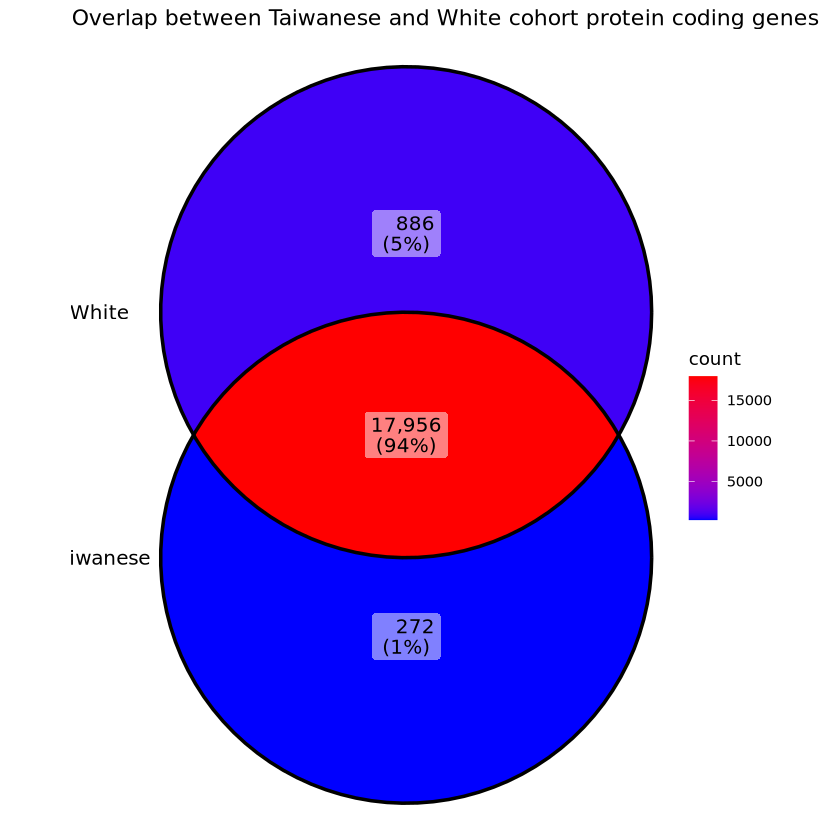

In [34]:
# Venn diagram of gene lists
taiwanese_genes <- colnames(taiwanese_expr)
white_genes <- colnames(white_expr)
listado <- list(Taiwanese = taiwanese_genes,
                 White = white_genes)
ggVennDiagram(listado)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort protein coding genes")


In [35]:
taiwanese_mirnas <- readRDS("taiwanese_cohort/mirna_pooled_tmm/datExpr_clean.rds")
white_mirnas <- readRDS("cohort_white/newmirna_pooled/datExpr_clean.rds")

# pass taiwanese mirnas from name to ID
new_taiwanese <- miRNA_NameToAccession(colnames(taiwanese_mirnas), version = "v22")

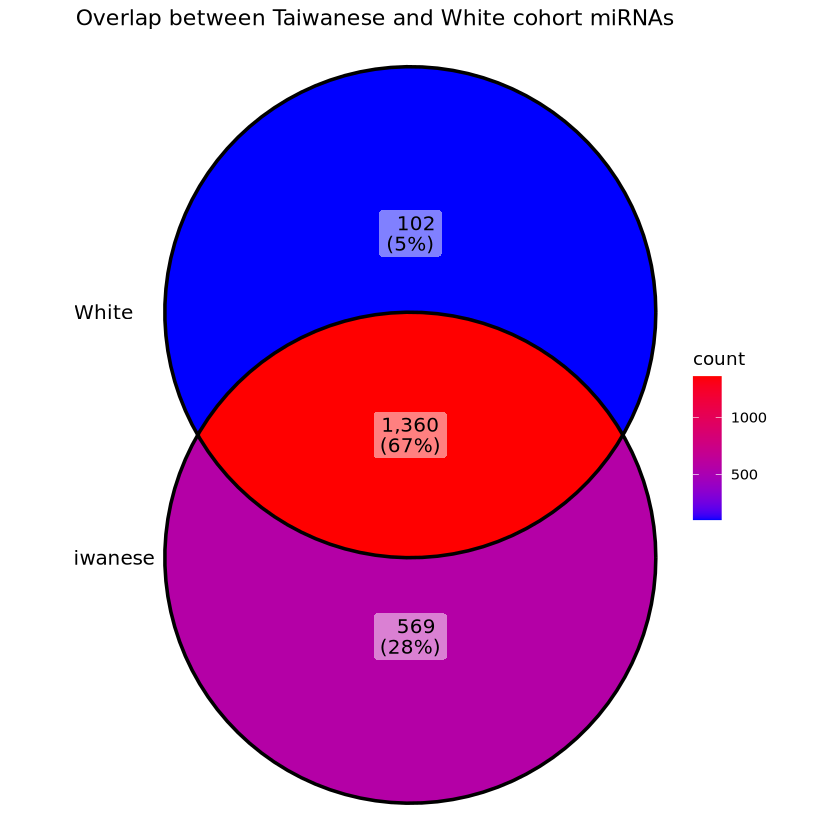

In [36]:
listado_mirna <- list(Taiwanese = new_taiwanese$Accession,
                      White = colnames(white_mirnas))

ggVennDiagram(listado_mirna)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort miRNAs")

In [37]:
# Load networks
taiwanese_path <- "taiwanese_cohort/count_matrices_by_geneid/ENCORI_filtered_edges_selected_modules_TAIWAN.tsv"
white_path <- "cohort_white/count_matrices_white_byFILENAME/ENCORI_filtered_edges_selected_modules_WHITE.tsv"

taiwanese_net <- read.table(taiwanese_path, sep="\t", header=TRUE)
white_net <- read.table(white_path, sep="\t", header=TRUE)

In [38]:
# also load differential expression table
de_taiwan_rna_path <- "taiwanese_cohort/count_matrices_by_geneid/DESeq2_RNA_results.tsv"
de_taiwan_mirna_path <- "taiwanese_cohort/count_matrices_by_geneid/DESeq2_miRNA_results.tsv"

de_white_rna_path <- "cohort_white/count_matrices_white_byFILENAME/DESeq2_RNA_results.tsv"
de_white_mirna_path <- "cohort_white/count_matrices_white_byFILENAME/DESeq2_miRNA_results.tsv"

taiwan_dernas <- read.table(de_taiwan_rna_path, header=TRUE, sep="\t", row.names=1)
taiwan_demirnas <- read.table(de_taiwan_mirna_path, header=TRUE, sep="\t", row.names=1)

white_dernas <- read.table(de_white_rna_path, header=TRUE, sep="\t", row.names=1)
white_demirnas <- read.table(de_white_mirna_path, header=TRUE, sep="\t", row.names=1)

In [39]:
# How many DEGs from TAIWAN
table(taiwan_dernas$Category)
# How many DEmiRNAs from TAIWAN
table(taiwan_demirnas$Category)

# How many DEGs from TAIWAN
table(white_dernas$Category)
# How many DEmiRNAs from TAIWAN
table(white_demirnas$Category)


 Down-regulated Not significant    Up-regulated 
           2358           12966            2904 


 Down-regulated Not significant    Up-regulated 
            107            1268             292 


 Down-regulated Not significant    Up-regulated 
           2257           14339            2246 


 Down-regulated Not significant    Up-regulated 
            228             815             164 

[1] 0.7796841

`geom_smooth()` using formula = 'y ~ x'


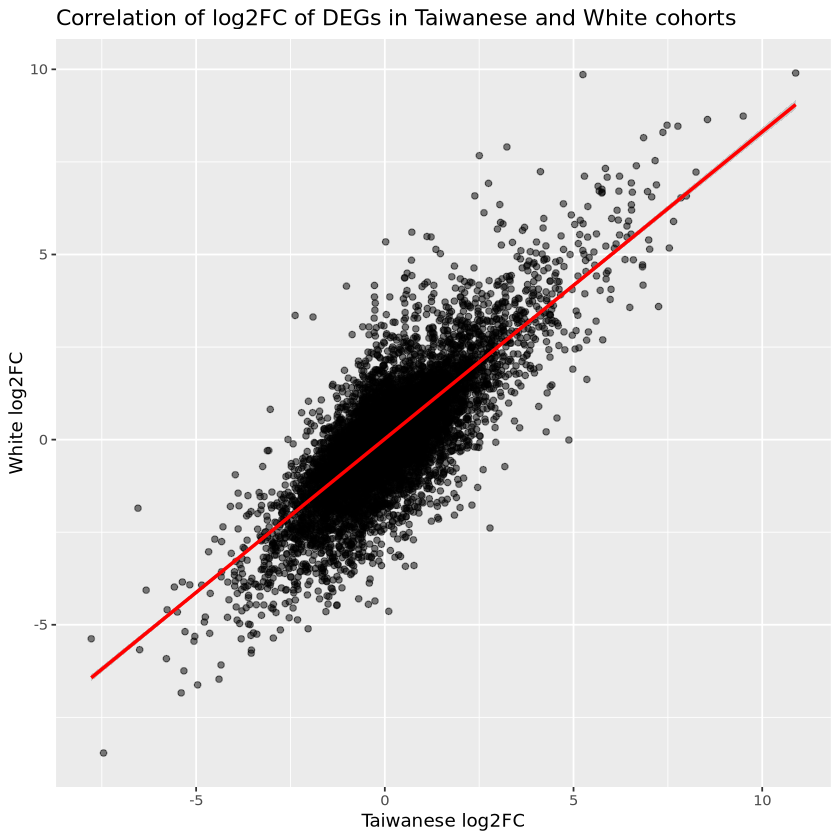

In [40]:
# correlate logFC of DEGs in both cohorts
# use all genes and color dots based on $Category
common_dernas <- intersect(rownames(taiwan_dernas), rownames(white_dernas))
taiwan_logFC <- taiwan_dernas[common_dernas, "log2FoldChange"]
white_logFC <- white_dernas[common_dernas, "log2FoldChange"]
cor(taiwan_logFC, white_logFC)

# make a plot of the correlation, color dots based on: significant in both, only in taiwan, only in white, none
df_logFC <- data.frame(Taiwan = taiwan_logFC, White = white_logFC)
ggplot(df_logFC, aes(x=Taiwan, y=White))+
  geom_point(alpha=0.5)+
  geom_smooth(method="lm", color="red")+
  ggtitle("Correlation of log2FC of DEGs in Taiwanese and White cohorts")+
  xlab("Taiwanese log2FC")+
  ylab("White log2FC")

[1] 0.03081966

`geom_smooth()` using formula = 'y ~ x'


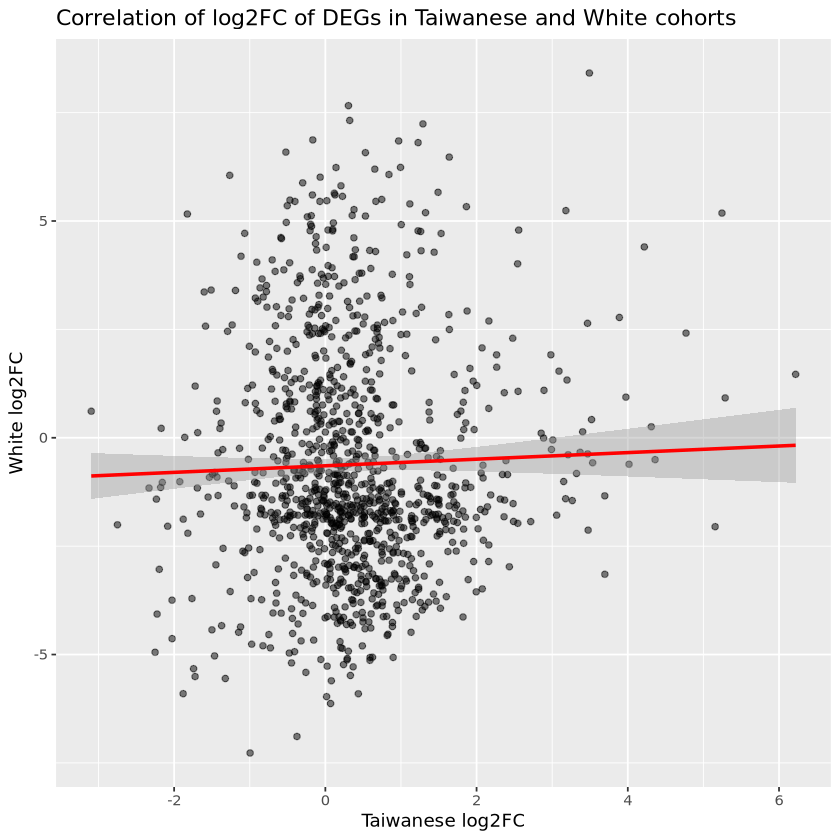

In [41]:
# correlate logFC of DEmiRNAs in both cohorts
common_demirnas <- intersect(rownames(taiwan_demirnas), rownames(white_demirnas))
taiwan_logFC <- taiwan_demirnas[common_demirnas, "log2FoldChange"]
white_logFC <- white_demirnas[common_demirnas, "log2FoldChange"]
cor(taiwan_logFC, white_logFC)

# make a plot of the correlation, color dots based on: significant in both, only in taiwan, only in white, none
df_logFC <- data.frame(Taiwan = taiwan_logFC, White = white_logFC)
ggplot(df_logFC, aes(x=Taiwan, y=White))+
  geom_point(alpha=0.5)+
  geom_smooth(method="lm", color="red")+
  ggtitle("Correlation of log2FC of DEGs in Taiwanese and White cohorts")+
  xlab("Taiwanese log2FC")+
  ylab("White log2FC")

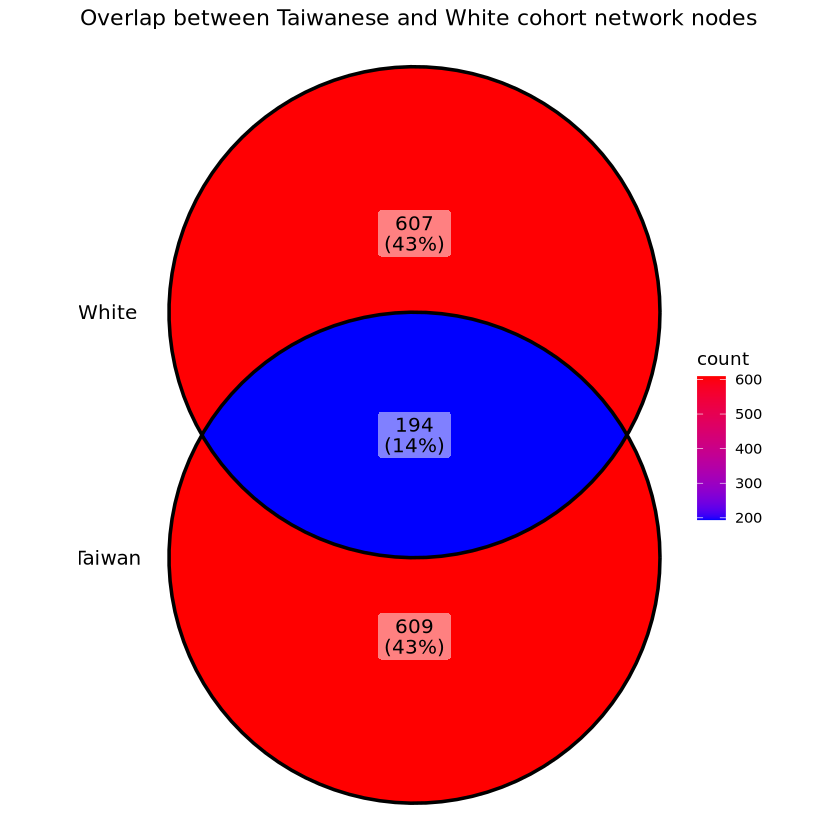

In [42]:
nodes_mirna_taiwan <- unique(taiwanese_net$miRNAid)
nodes_rna_taiwan <- unique(taiwanese_net$geneID)

nodes_taiwan <- union(nodes_mirna_taiwan, nodes_rna_taiwan)

nodes_mirna_white <- unique(white_net$miRNAid)
nodes_rna_white <- unique(white_net$geneID)

nodes_white <- union(nodes_mirna_white, nodes_rna_white)

listado_nodes <- list(Taiwan = nodes_taiwan,
                      White = nodes_white)
ggVennDiagram(listado_nodes)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort network nodes")

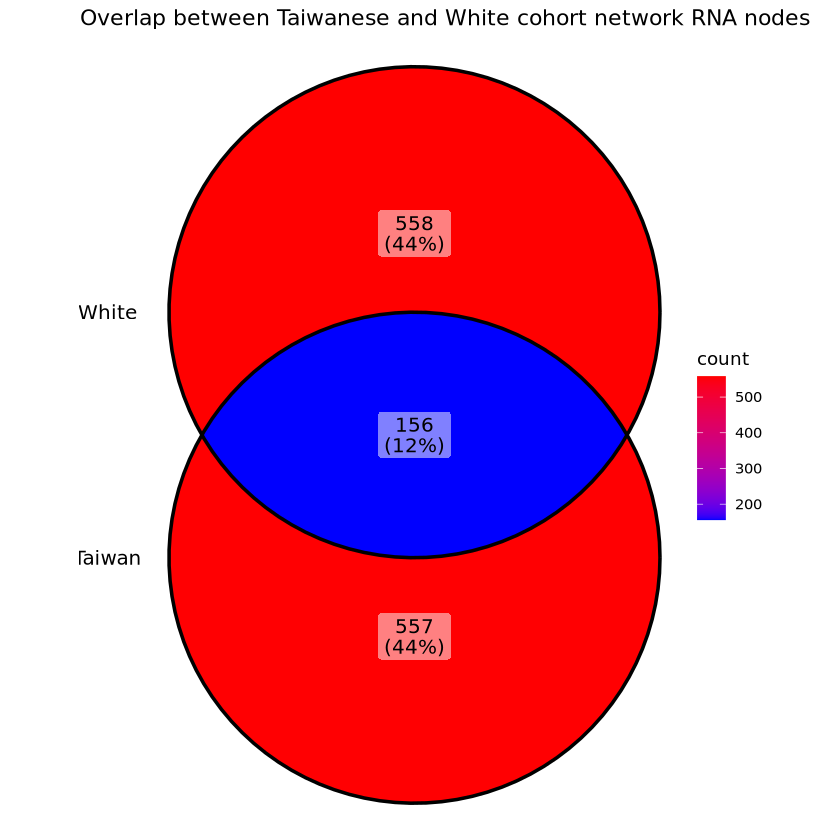

In [43]:
listado_nodes_rna <- list(Taiwan = nodes_rna_taiwan,
                      White = nodes_rna_white)
ggVennDiagram(listado_nodes_rna)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort network RNA nodes")

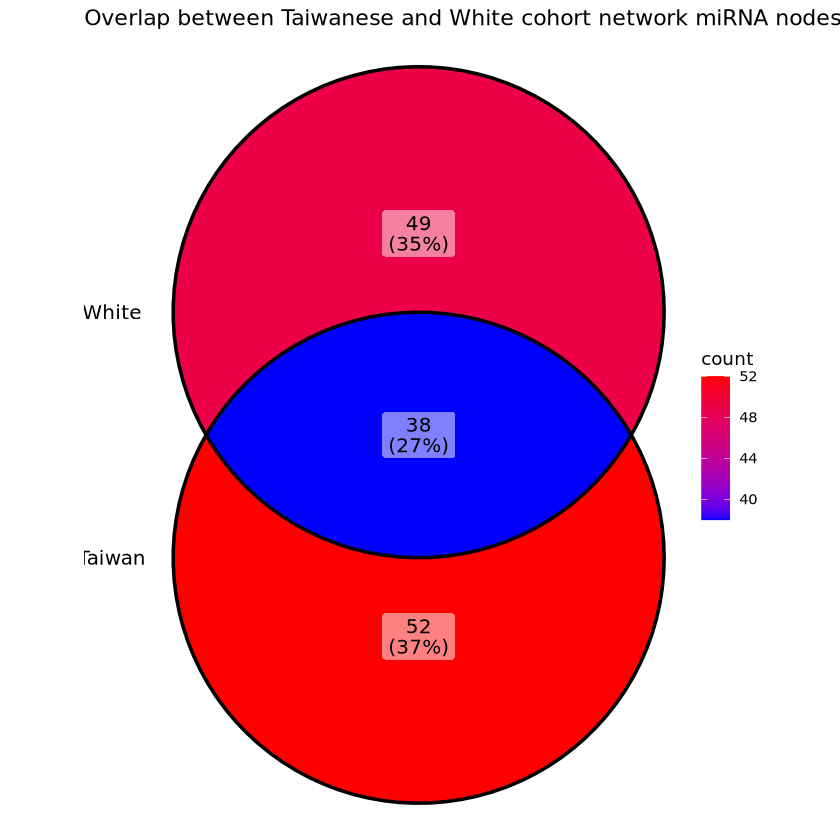

In [44]:
listado_nodes_mirna <- list(Taiwan = nodes_mirna_taiwan,
                      White = nodes_mirna_white)
ggVennDiagram(listado_nodes_mirna)+
  scale_fill_gradient(low="blue", high = "red")+
  ggtitle("Overlap between Taiwanese and White cohort network miRNA nodes")

In [45]:
intersect(nodes_mirna_taiwan, nodes_mirna_white)

[1] "MIMAT0000063" "MIMAT0000067" "MIMAT0000070" "MIMAT0000075" "MIMAT0000076"
 [6] "MIMAT0000081" "MIMAT0000082" "MIMAT0000083" "MIMAT0000085" "MIMAT0000099"
[11] "MIMAT0000222" "MIMAT0000242" "MIMAT0000250" "MIMAT0000254" "MIMAT0000259"
[16] "MIMAT0000281" "MIMAT0000414" "MIMAT0000419" "MIMAT0000423" "MIMAT0000425"
[21] "MIMAT0000427" "MIMAT0000431" "MIMAT0000433" "MIMAT0000437" "MIMAT0000438"
[26] "MIMAT0000443" "MIMAT0000444" "MIMAT0000445" "MIMAT0000450" "MIMAT0000455"
[31] "MIMAT0000456" "MIMAT0000457" "MIMAT0000458" "MIMAT0000460" "MIMAT0005951"
[36] "MIMAT0007881" "MIMAT0017950" "MIMAT0019776"

In [46]:
g_taiwan <- graph_from_data_frame(taiwanese_net[, c("miRNAid", "geneID", "weight")], directed=TRUE)
g_white <- graph_from_data_frame(white_net[, c("miRNAid", "geneID", "weight")], directed=TRUE)

In [47]:
stats_taiwan <- calcular_topologia(g_taiwan, "Taiwanese Network")
stats_white <- calcular_topologia(g_white, "White Network")
stats <- rbind(stats_taiwan, stats_white)
stats

Red,Num_Nodos,Num_Aristas,Densidad,Clustering_Coef,Grado_Promedio,Diametro
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Taiwanese Network,803,5989,0.009299603,0,14.91656,9
White Network,801,5445,0.008497191,0,13.59551,7


In [48]:
edges_taiwan <- as_ids(E(g_taiwan))
edges_white <- as_ids(E(g_white))

intersection <- length(intersect(edges_taiwan, edges_white))
union <- length(union(edges_taiwan, edges_white))
jaccard <- intersection/union
jaccard

[1] 0.04678202

In [49]:
taiwan_lost <- setdiff(edges_taiwan, edges_white)
taiwan_gained <- setdiff(edges_white, edges_taiwan)

length(taiwan_lost)
length(taiwan_gained)

[1] 5478

[1] 4934

In [50]:
# IDEA: ONLY DO ENRICHMENT ON THE GENES THAT ARE UNIQUE TO EACH NETWORK
nodes_taiwan_unique <- setdiff(nodes_rna_taiwan, nodes_rna_white)
nodes_white_unique <- setdiff(nodes_rna_white, nodes_rna_taiwan)
length(nodes_taiwan_unique)
length(nodes_white_unique)

[1] 557

[1] 558

In [51]:
# Enrichment on the taiwanese nodes
ego_taiwan <- enrichGO(gene         = nodes_taiwan_unique,
                OrgDb        = org.Hs.eg.db,
                keyType      = "ENSEMBL",
                ont          = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.01,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

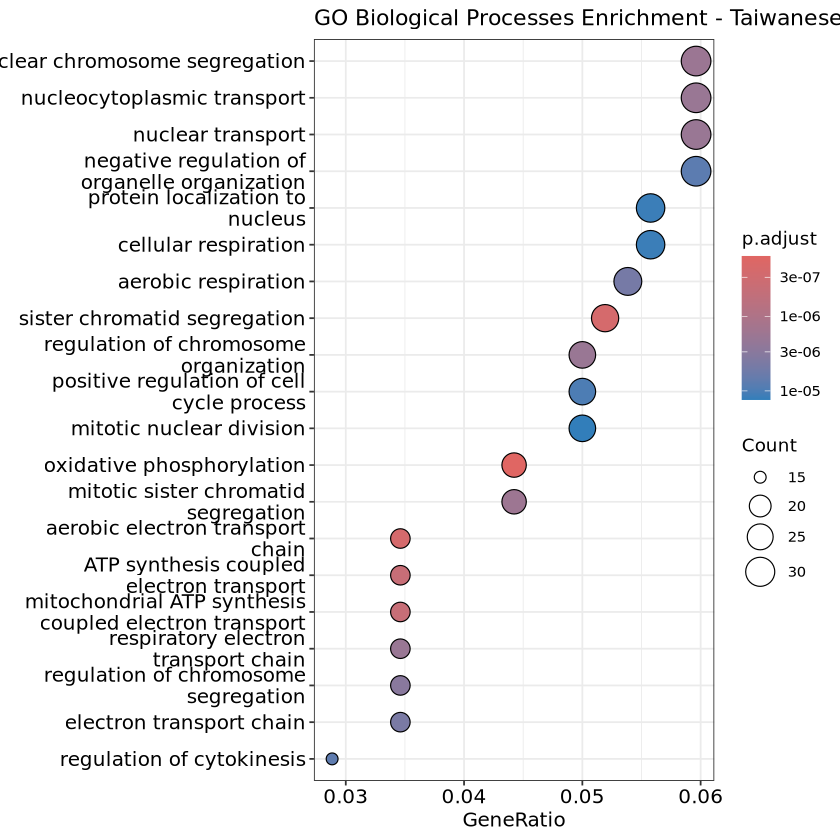

In [52]:
# visualize the enrichment
dotplot(ego_taiwan, showCategory=20) + ggtitle("GO Biological Processes Enrichment - Taiwanese Network Genes")

In [53]:
# enrichment on the white nodes
ego_white <- enrichGO(gene = nodes_white_unique,
                OrgDb        = org.Hs.eg.db,
                keyType      = "ENSEMBL",
                ont          = "BP",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.01,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

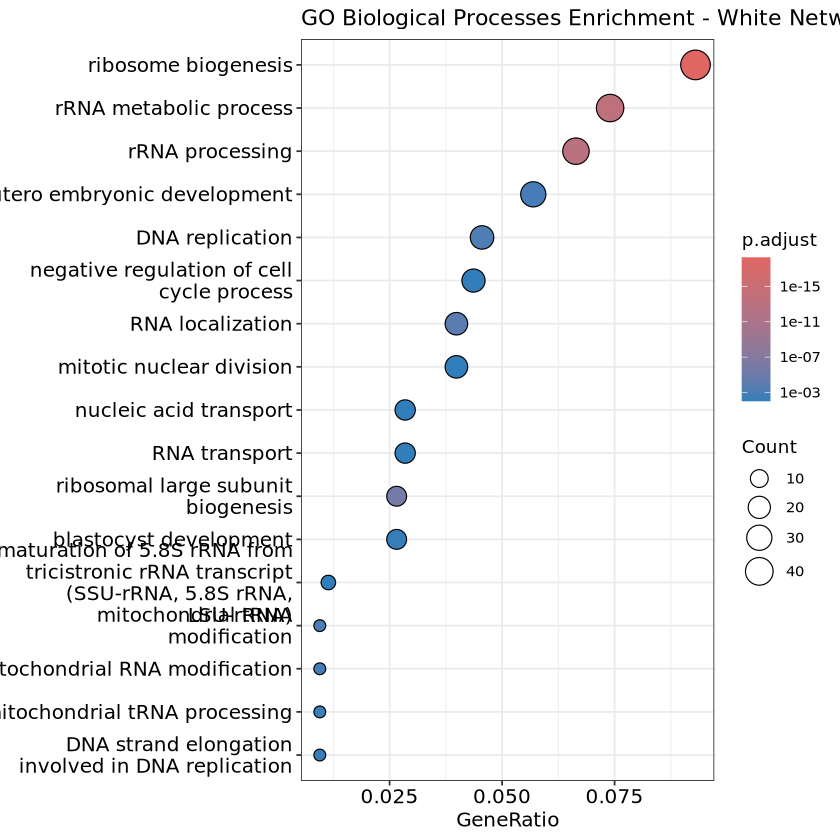

In [54]:
# visualize the enrichment
dotplot(ego_white, showCategory=20) + ggtitle("GO Biological Processes Enrichment - White Network Genes")